## 1. Загрузка данных и первичный обзор

In [1]:
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')

PALETTE = sns.color_palette('deep')
sns.set_theme(style='darkgrid', palette=PALETTE)
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

/home/offyne/ML_COURSE/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download('taeefnajib/used-car-price-prediction-dataset')
print('Путь к файлам датасета:', path)

df = pd.read_csv(path + '/used_cars.csv')

Путь к файлам датасета: /home/offyne/.cache/kagglehub/datasets/taeefnajib/used-car-price-prediction-dataset/versions/1


In [3]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [5]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [6]:
df.isna().sum().sort_values(ascending=False)

clean_title     596
fuel_type       170
accident        113
brand             0
milage            0
model_year        0
model             0
engine            0
ext_col           0
transmission      0
int_col           0
price             0
dtype: int64

In [7]:
df[['price', 'milage']].head(10)

,price,milage
0,"$10,300","51,000 mi."
1,"$38,005","34,742 mi."
2,"$54,598","22,372 mi."
3,"$15,500","88,900 mi."
4,"$34,999","9,835 mi."
5,"$14,798","136,397 mi."
6,"$31,000","84,000 mi."
7,"$7,300","242,000 mi."
8,"$41,927","23,436 mi."
9,"$69,950","34,000 mi."


## 2. Предобработка данных

Цена и пробег записаны как строки, поэтому сначала нужно привести их к нормальным числам.

In [8]:
df['price'] = (
    df['price']
    .str.strip()
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [9]:
df['milage'] = (
    df['milage']
    .str.strip()
    .str.replace('mi', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('.', '', regex=False)
    .astype(int)
)

In [10]:
df[['price', 'milage']].head(10)

,price,milage
0,10300,51000
1,38005,34742
2,54598,22372
3,15500,88900
4,34999,9835
5,14798,136397
6,31000,84000
7,7300,242000
8,41927,23436
9,69950,34000


In [11]:
df['price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

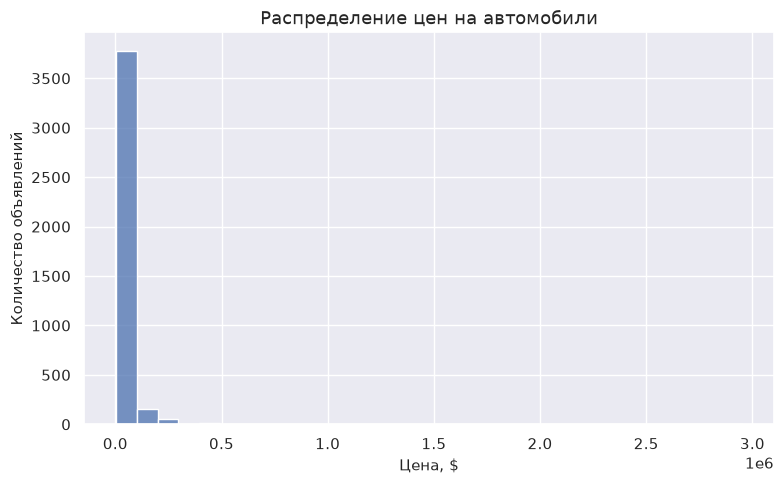

In [12]:
fig, ax = plt.subplots()
sns.histplot(df['price'], bins=30, color=PALETTE[0], ax=ax)
ax.set_title('Распределение цен на автомобили')
ax.set_xlabel('Цена, $')
ax.set_ylabel('Количество объявлений')
plt.tight_layout()
plt.show()

## 3. Проверка гипотез

Гипотеза 1. Год выпуска автомобиля и его пробег имеют наиболее сильную корреляцию с ценой среди числовых признаков.

Гипотеза 2. Масштабирование признаков и логарифмирование целевой переменной существенно улучшают качество линейных моделей.

Гипотеза 3. Использование регуляризации предотвращает переобучение и показывает лучшие результаты по метрикам качества и ошибкам по сравнению с обычной линейной регрессией.

Гипотеза 4. Модель, обученная на полностью предобработанных данных, показывает более высокую точность, чем базовая модель на сырых данных.

Гипотеза 5: Модели на основе деревьев решений (Decision Tree) превосходят линейные модели (Ridge) по метрикам качества, так как лучше улавливают нелинейные зависимости в данных.

In [13]:
df[['price', 'milage', 'model_year']].corr()

,price,milage,model_year
price,1.000000,-0.305528,0.199496
milage,-0.305528,1.000000,-0.617720
model_year,0.199496,-0.617720,1.000000


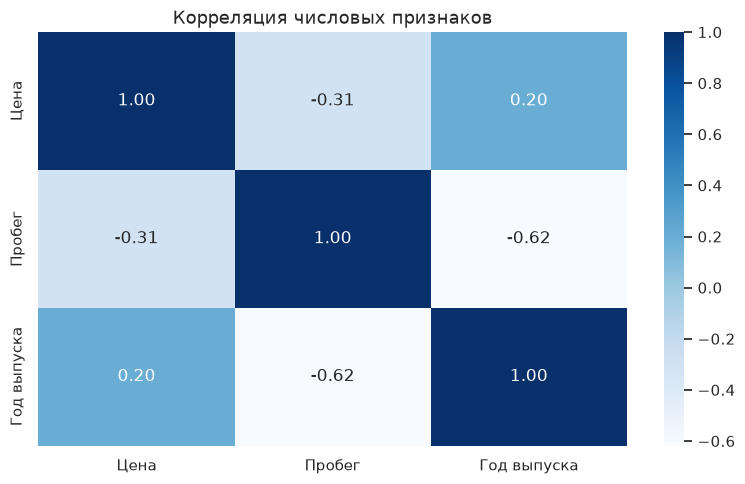

In [14]:
corr = df[['price', 'milage', 'model_year']].corr()
labels = {'price': 'Цена', 'milage': 'Пробег', 'model_year': 'Год выпуска'}
corr_ru = corr.rename(columns=labels, index=labels)

fig, ax = plt.subplots()
sns.heatmap(corr_ru, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

По первой гипотезе получилось не совсем так, как я думал: пробег с ценой связан сильнее, чем год выпуска, так что подтвердилась она только частично.

## 4. Обучение и оценка моделей

In [15]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
numeric_features = ['model_year', 'milage']
categorical_features = [
    'brand',
    'model',
    'fuel_type',
    'engine',
    'transmission',
    'ext_col',
    'int_col',
    'accident',
    'clean_title',
]

In [17]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(min_frequency=10, handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

In [18]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])

In [19]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [20]:
model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['brand','model','model_year',...,'int_col','accident','clean_title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colum

In [21]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [22]:
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.4f}')

RMSE: 138793.67
MAE: 21166.41
R²: 0.0575


In [23]:
predictions = pd.DataFrame({
    'Фактическая цена': y_test.values,
    'Прогноз': y_pred,
})
predictions.head(10)

,Фактическая цена,Прогноз
0,28000,31418.930561
1,5900,12716.445039
2,41000,41179.995618
3,40250,50712.847781
4,77999,34481.112958
5,35899,33750.106860
6,36000,46341.133976
7,47214,49697.822246
8,30900,16818.364259
9,11000,12785.368455


In [24]:
print(f'Автомобилей дороже $150 000: {(df["price"] > 150000).sum()}')

Автомобилей дороже $150 000: 118


Теперь сравню линейную регрессию и Ridge — это как раз вторая гипотеза.

In [25]:
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()),
])
model_lr.fit(X_train, y_train_log)

y_pred_log_lr = model_lr.predict(X_test)
y_pred_lr = np.expm1(y_pred_log_lr)

In [26]:
model_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0)),
])
model_ridge.fit(X_train, y_train_log)

y_pred_log_ridge = model_ridge.predict(X_test)
y_pred_ridge = np.expm1(y_pred_log_ridge)

In [27]:
print('Линейная регрессия')
print(f'R² (лог. шкала): {r2_score(y_test_log, y_pred_log_lr):.4f}')
print(f'R² (реальная цена): {r2_score(y_test, y_pred_lr):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_lr):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}')

print()
print('Регрессия Ridge')
print(f'R² (лог. шкала): {r2_score(y_test_log, y_pred_log_ridge):.4f}')
print(f'R² (реальная цена): {r2_score(y_test, y_pred_ridge):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_ridge):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}')

Линейная регрессия
R² (лог. шкала): 0.6989
R² (реальная цена): 0.0575
RMSE: 138793.67
MAE: 21166.41

Регрессия Ridge
R² (лог. шкала): 0.6993
R² (реальная цена): 0.0588
RMSE: 138702.95
MAE: 21050.23


Ridge действительно чуть лучше, но разница совсем небольшая при alpha=1.0, так что вторая гипотеза скорее подтвердилась.

Следующая проверка — нужен ли вообще StandardScaler.

In [28]:
preprocessor_no_scale = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(min_frequency=10, handle_unknown='ignore')),
        ]), categorical_features),
    ]
)

pipe_lr_no_scale = Pipeline([
    ('prep', preprocessor_no_scale),
    ('reg', LinearRegression()),
])
pipe_lr_no_scale.fit(X_train, y_train_log)
pred_lr_no_scale = np.expm1(pipe_lr_no_scale.predict(X_test))

pipe_ridge_no_scale = Pipeline([
    ('prep', preprocessor_no_scale),
    ('reg', Ridge(alpha=1.0)),
])
pipe_ridge_no_scale.fit(X_train, y_train_log)
pred_ridge_no_scale = np.expm1(pipe_ridge_no_scale.predict(X_test))

In [29]:
print('Линейная регрессия')
print(f'Без StandardScaler: R² = {r2_score(y_test, pred_lr_no_scale):.4f}, MAE = {mean_absolute_error(y_test, pred_lr_no_scale):.2f}')
print(f'С StandardScaler:   R² = {r2_score(y_test, y_pred_lr):.4f}, MAE = {mean_absolute_error(y_test, y_pred_lr):.2f}')

print()
print('Регрессия Ridge')
print(f'Без StandardScaler: R² = {r2_score(y_test, pred_ridge_no_scale):.4f}, MAE = {mean_absolute_error(y_test, pred_ridge_no_scale):.2f}')
print(f'С StandardScaler:   R² = {r2_score(y_test, y_pred_ridge):.4f}, MAE = {mean_absolute_error(y_test, y_pred_ridge):.2f}')

Линейная регрессия
Без StandardScaler: R² = 0.0404, MAE = 24610.29
С StandardScaler:   R² = 0.0575, MAE = 21166.41

Регрессия Ridge
Без StandardScaler: R² = 0.0297, MAE = 27255.26
С StandardScaler:   R² = 0.0588, MAE = 21050.23


Тут всё однозначно: без масштабирования модель заметно хуже, третья гипотеза полностью подтверждается.

In [30]:
preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
    ]
)

pipe_baseline = Pipeline([
    ('prep', preprocessor_baseline),
    ('reg', Ridge(alpha=1.0)),
])

pipe_baseline.fit(X_train, y_train_log)
pred_log_base = pipe_baseline.predict(X_test)
pred_base = np.expm1(pred_log_base)

In [31]:
print('Бейзлайн (только числовые признаки)')
print(f'R² (лог. шкала): {r2_score(y_test_log, pred_log_base):.4f}')
print(f'R² (реальная цена): {r2_score(y_test, pred_base):.4f}')
print(f'MAE: {mean_absolute_error(y_test, pred_base):.2f}')

print()
print('Полная модель (числовые + категориальные OHE)')
print(f'R² (лог. шкала): {r2_score(y_test_log, y_pred_log_ridge):.4f}')
print(f'R² (реальная цена): {r2_score(y_test, y_pred_ridge):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}')

Бейзлайн (только числовые признаки)
R² (лог. шкала): 0.5265
R² (реальная цена): 0.0138
MAE: 26911.29

Полная модель (числовые + категориальные OHE)
R² (лог. шкала): 0.6993
R² (реальная цена): 0.0588
MAE: 21050.23


Разница большая, категории реально добавляют качество — четвёртая гипотеза подтверждается.

И последнее — попробую дерево решений вместо Ridge и посмотрю, станет ли лучше.

In [32]:
pipe_tree = Pipeline([
    ('prep', preprocessor),
    ('reg', DecisionTreeRegressor(max_depth=10, random_state=42)),
])

pipe_tree.fit(X_train, y_train_log)

pred_log_tree = pipe_tree.predict(X_test)
pred_tree = np.expm1(pred_log_tree)

In [33]:
print('Регрессия Ridge')
print(f'R² (лог. шкала): {r2_score(y_test_log, y_pred_log_ridge):.4f}')
print(f'R² (реальная цена): {r2_score(y_test, y_pred_ridge):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}')

print()
print('Дерево решений (max_depth=10)')
print(f'R² (лог. шкала): {r2_score(y_test_log, pred_log_tree):.4f}')
print(f'R² (реальная цена): {r2_score(y_test, pred_tree):.4f}')
print(f'MAE: {mean_absolute_error(y_test, pred_tree):.2f}')

Регрессия Ridge
R² (лог. шкала): 0.6993
R² (реальная цена): 0.0588
MAE: 21050.23

Дерево решений (max_depth=10)
R² (лог. шкала): 0.5507
R² (реальная цена): 0.0735
MAE: 25355.14


Не стало. Дерево проигрывает Ridge по метрикам, так что пятая гипотеза не подтвердилась.

## 5. Итоговые выводы

В целом по данным видно, что на цену сильнее всего давит пробег, а год выпуска тоже важен, но поменьше. Лучше всего из того, что я пробовал, отработала Ridge с onehotсoder'ом категорий и логарифмированием цены. Масштабирование и нормальная обработка категориальных признаков реально нужны — без них качество сильно падает. Дерево с max_depth=10 переобучается и в итоге хуже Ridge. Если продолжать, наверное имеет смысл покрутить гиперпараметры Ridge или попробовать бустинг, но это уже за рамками этого дз.